In [1]:
import duckdb
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from srm import downscaling_utils, run_bcsd

# 0. Get data

In [2]:
RUN_PARAMETERS = {
    "gcm": "CESM2-WACCM",
    "train_period_start": 1978,
    "train_period_end": 2014,
    "predict_period_start": 2015,
    "predict_period_end": 2100,
    "var_name": "pr",
}

In [3]:
dict_all = run_bcsd.get_all_data(
    gcm=RUN_PARAMETERS["gcm"], var_name=RUN_PARAMETERS["var_name"], verbose=True
)

Loaded data: 1.15 seconds
Subset time: 0.00 seconds


In [4]:
for key in dict_all:
    print(key)

model_hist
obs
model_scenario


In [5]:
# Temporary fix for precip units inconsistency
dict_all["model_hist"] = dict_all["model_hist"] * 1000
dict_all["model_scenario"] = dict_all["model_scenario"] * 1000

### Subset data to demo region (South Africa)

In [6]:
df = duckdb.sql(
    """install httpfs; load httpfs; install spatial; load spatial; SELECT name, ST_AsText(geom) as geometry FROM ST_Read('https://carbonplan-data.s3.us-west-2.amazonaws.com/countries-50m.json') WHERE NAME = 'South Africa'"""
).df()
df["geometry"] = gpd.GeoSeries.from_wkt(df["geometry"])
south_africa_geom = gpd.GeoDataFrame(df, geometry="geometry")

# Set bounds as a couple of degrees around South Africa
lon_min, lat_min, lon_max, lat_max = south_africa_geom.total_bounds

In [7]:
for key in dict_all:
    if key in ["obs"]:
        dict_all[key] = downscaling_utils.subset_space(
            dict_all[key], coord_bounds_list=[lat_min - 2, lat_max + 2, lon_min - 2, lon_max + 2]
        )

    else:
        dict_all[key] = downscaling_utils.subset_space(
            dict_all[key], coord_bounds_list=[lat_min - 1, lat_max + 1, lon_min - 1, lon_max + 1]
        )

# 1. Preprocess data

In [8]:
RECHUNK_WORKFLOW = True  # flag: whether to rechunk data depending on the step
VERBOSE = True

In [9]:
dict_all = run_bcsd.preprocess_data(
    dict_all,
    train_period_start=RUN_PARAMETERS["train_period_start"],
    train_period_end=RUN_PARAMETERS["train_period_end"],
    predict_period_start=RUN_PARAMETERS["predict_period_start"],
    predict_period_end=RUN_PARAMETERS["predict_period_end"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=False,
)

Rechunked obs to full space: 4.91 seconds
Interpolated obs to coarse grid: 55.05 seconds
Rechunked all to full time: 1.36 seconds


# 2. Bias correct with quantile mapping

In [11]:
dict_all = run_bcsd.bias_correct(
    dict_all=dict_all,
    var_name=RUN_PARAMETERS["var_name"],
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    detrend_data=False,
    mapping_type="parametric",
)

Quantile mapped historical: 37.75 seconds
Quantile mapped future: 67.07 seconds


# 3. Downscale

In [12]:
dict_all = run_bcsd.spatially_disaggregate(
    dict_all=dict_all,
    verbose=VERBOSE,
    rechunk_workflow=RECHUNK_WORKFLOW,
    method="divide",
    clim_method="simple",
)

Rechunked all to full space: 0.23 seconds
Downscaled historical: 7.15 seconds
Downscaled future: 8.65 seconds


In [15]:
for key in dict_all:
    print(key)
    print((dict_all[key] < 0).sum().values)

model_hist
0
obs
0
model_scenario
0
obs_coarse
0
scenario_detrended
0
model_hist_debiased
0
scenario_debiased
0
model_hist_debiased_downscaled
30343
scenario_debiased_downscaled
71837


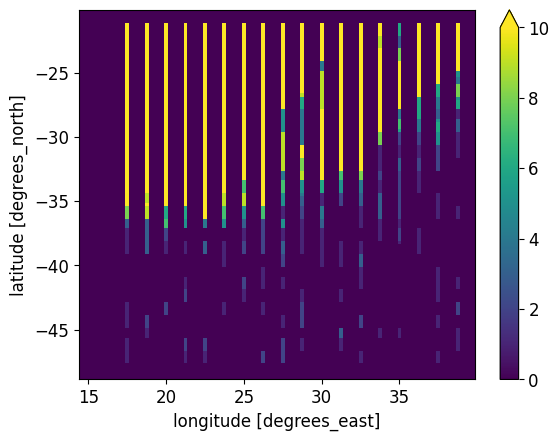

In [25]:
(dict_all["model_hist_debiased_downscaled"] < 0).sum(dim="time").plot(vmax=10)

In [ ]:
(dict_all["scenario_debiased_downscaled"] < 0).sum(dim="time").plot(vmax=10)

# Look at results at Cape Town, South Africa

In [16]:
cities = gpd.read_file(
    "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_populated_places_simple.zip",
    columns=["name", "sov0name", "geometry"],
)
sa_cities = cities[cities["sov0name"] == "South Africa"]
cape_town_x, cape_town_y = (
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
    float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),
)

/tmp/ipykernel_1910/1595652233.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.x),
/tmp/ipykernel_1910/1595652233.py:8: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  float(sa_cities[sa_cities["name"] == "Cape Town"].geometry.y),


In [17]:
dict_all_CT = {}
for key, ds in dict_all.items():
    print(key)
    ds_CT = ds.sel(lat=cape_town_y, lon=cape_town_x, method="nearest").compute()
    dict_all_CT[key] = ds_CT

model_hist
obs
model_scenario
obs_coarse
scenario_detrended
model_hist_debiased
scenario_debiased
model_hist_debiased_downscaled
scenario_debiased_downscaled


In [18]:
dict_all_CT["model_scenario_debiased"] = dict_all_CT["scenario_debiased"]
dict_all_CT["model_scenario_debiased_downscaled"] = dict_all_CT["scenario_debiased_downscaled"]

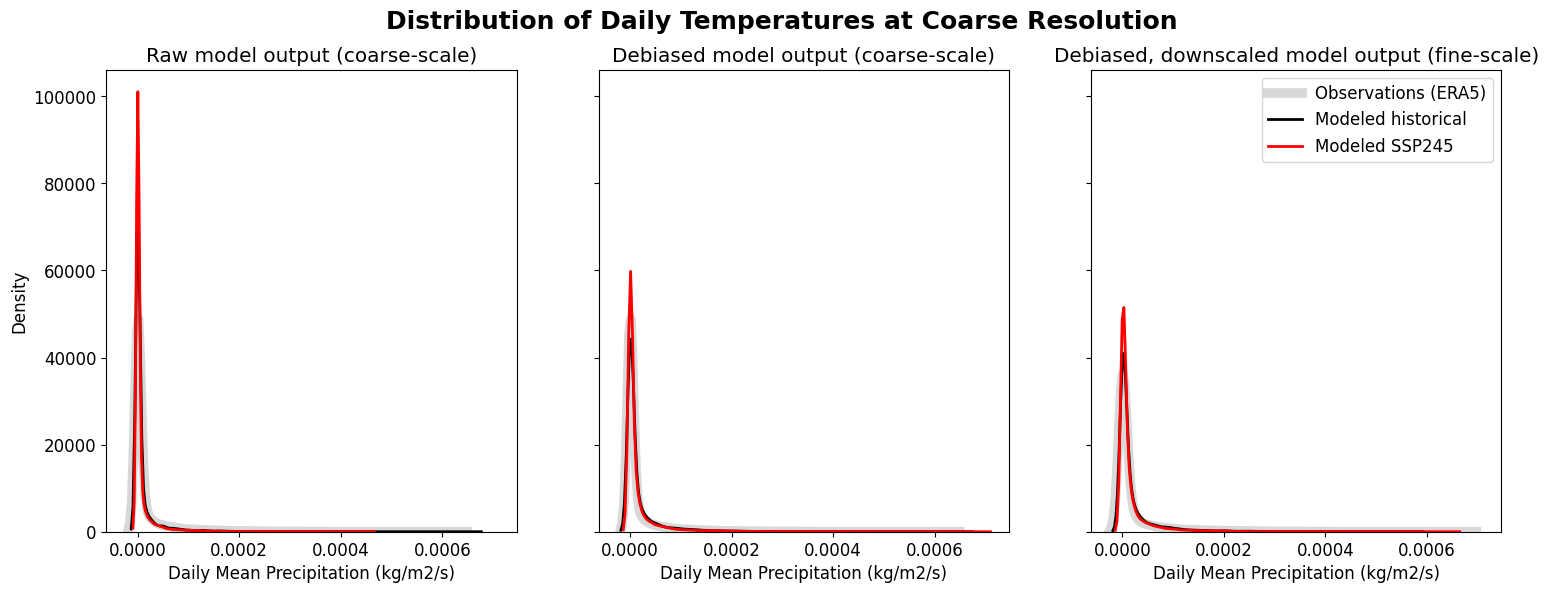

In [24]:
colors = ["black", "red"]
labels = ["Modeled historical", "Modeled SSP245"]
dataset_keys = ["model_hist", "model_scenario"]

plt.rcParams["font.size"] = 12


def format_subplot(res="coarse"):
    if res == "coarse":
        sns.kdeplot(
            dict_all_CT["obs_coarse"].as_numpy(),
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    elif res == "fine":
        sns.kdeplot(
            dict_all_CT["obs"],
            label="Observations (ERA5)",
            color="gray",
            linewidth=7,
            alpha=0.3,
            linestyle="-",
        )
    # plt.yscale("symlog", linthresh=100)
    plt.xlabel("Daily Mean Precipitation (kg/m2/s)")


fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharey=True, sharex=True)
plt.subplot(1, 3, 1)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key], label=labels[i], color=colors[i], linewidth=2, linestyle="-", ax=axs[0]
    )
plt.title("Raw model output (coarse-scale)")


plt.subplot(1, 3, 2)
format_subplot(res="coarse")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased"],
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
        ax=axs[1],
    )
plt.title("Debiased model output (coarse-scale)")


plt.subplot(1, 3, 3)
format_subplot(res="fine")
for i, key in enumerate(dataset_keys):
    sns.kdeplot(
        dict_all_CT[key + "_debiased_downscaled"],
        label=labels[i],
        color=colors[i],
        linewidth=2,
        linestyle="-",
        ax=axs[2],
    )
plt.title("Debiased, downscaled model output (fine-scale)")

plt.suptitle(
    "Distribution of Daily Temperatures at Coarse Resolution",
    fontsize=18,
    fontweight="bold",
)

plt.legend(fontsize=12)

Text(0.5, 1.0, 'Raw coarse model data')

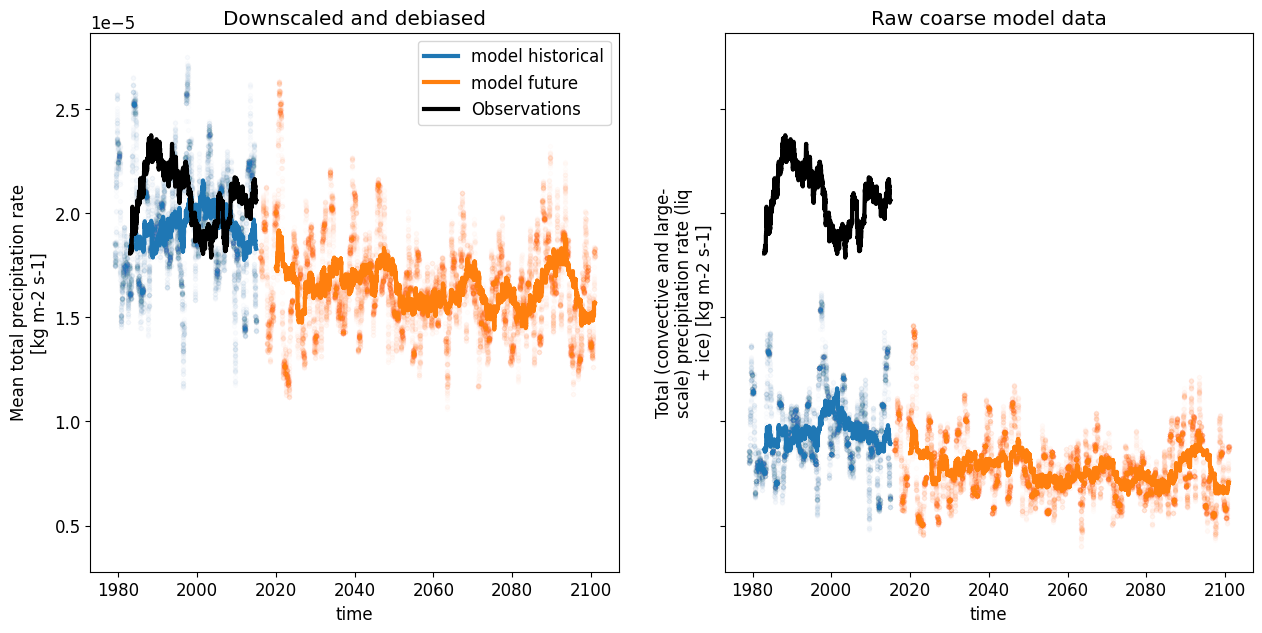

In [20]:
[fig, ax] = plt.subplots(nrows=1, ncols=2, sharey=True, figsize=(15, 7))

plt.subplot(1, 2, 1)
dict_all_CT["model_hist_debiased_downscaled"].rolling(time=365).mean().plot(
    marker=".",
    linewidth=0,
    alpha=0.01,
    color="C0",
)
dict_all_CT["model_hist_debiased_downscaled"].rolling(time=365 * 5).mean().plot(
    color="C0", linewidth=3, label="model historical"
)

dict_all_CT["scenario_debiased_downscaled"].rolling(time=365).mean().plot(
    marker=".", linewidth=0, alpha=0.01, color="C1"
)
dict_all_CT["scenario_debiased_downscaled"].rolling(time=365 * 5).mean().plot(
    color="C1", linewidth=3, label="model future"
)
dict_all_CT["obs"].rolling(time=365 * 5).mean().plot(color="k", linewidth=3, label="Observations")
ax[0].set_title("Downscaled and debiased")
plt.legend()

plt.subplot(1, 2, 2)
dict_all_CT["model_hist"].rolling(time=365).mean().plot(
    marker=".", linewidth=0, alpha=0.01, color="C0"
)
dict_all_CT["model_hist"].rolling(time=365 * 5).mean().plot(color="C0", linewidth=3)
dict_all_CT["obs"].rolling(time=365 * 5).mean().plot(color="k", linewidth=3, label="Observations")

dict_all_CT["model_scenario"].rolling(time=365).mean().plot(
    marker=".", linewidth=0, alpha=0.01, color="C1"
)
dict_all_CT["model_scenario"].rolling(time=365 * 5).mean().plot(color="C1", linewidth=3)
ax[1].set_title("Raw coarse model data")